#   Salary Prediction Model
**Dataset:** `cleaned_jobs.csv` 
**Target:** `normalized_salary` (annual USD)  
**Goal:** Train a model to predict salary from job features, evaluate it thoroughly, and export it for Streamlit integration.

In [2]:
!pip install scikit-learn==1.7.1

  Using cached scikit_learn-1.7.1-cp312-cp312-win_amd64.whl.metadata (11 kB)
Using cached scikit_learn-1.7.1-cp312-cp312-win_amd64.whl (8.7 MB)
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.5.1
    Uninstalling scikit-learn-1.5.1:
      Successfully uninstalled scikit-learn-1.5.1


## 1. Imports & Setup

In [3]:
import pandas as pd
import numpy as np
import re
import warnings
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

print('Libraries loaded')

Libraries loaded


In [4]:
warnings.filterwarnings('ignore')
sns.set_theme(style='darkgrid', palette='muted')
pd.set_option('display.float_format', '${:,.0f}'.format)

## 2. Load & Inspect Data

In [5]:
df = pd.read_csv('data/cleaned_jobs.csv')
print(f'Shape: {df.shape}')
print(f'\nColumns: {df.columns.tolist()}')
df.head(3)

Shape: (35563, 18)

Columns: ['company_name', 'title', 'title_clean', 'job_category', 'description', 'description_clean', 'tokens', 'extracted_skills', 'tech_skills', 'soft_skills', 'location', 'formatted_experience_level', 'work_type', 'remote_status', 'normalized_salary', 'listed_date', 'listed_month', 'listed_week']


,company_name,title,title_clean,job_category,description,description_clean,tokens,extracted_skills,tech_skills,soft_skills,location,formatted_experience_level,work_type,remote_status,normalized_salary,listed_date,listed_month,listed_week
0,Corcoran Sawyer Smith,Marketing Coordinator,marketing coordinator,Marketing & Creative,Job descriptionA leading real estate firm in N...,job descriptiona leading real estate firm in n...,"['job', 'descriptiona', 'leading', 'real', 'es...","['adobe', 'microsoft office', 'monday']","['adobe', 'microsoft office', 'monday']",[],"Princeton, NJ",NaN,FULL_TIME,On-site,"$38,480",2024-04-17 23:45:08,2024-04,2024-04-15/2024-04-21
1,The National Exemplar,Assitant Restaurant Manager,assitant restaurant manager,Retail & Hospitality,The National Exemplar is accepting application...,the national exemplar is accepting application...,"['national', 'exemplar', 'accepting', 'applica...",[],[],[],"Cincinnati, OH",NaN,FULL_TIME,On-site,"$55,000",2024-04-16 14:26:54,2024-04,2024-04-15/2024-04-21
2,"Abrams Fensterman, LLP",Senior Elder Law / Trusts and Estates Associat...,senior elder law / trusts and estates associat...,Legal,Senior Associate Attorney - Elder Law / Trusts...,senior associate attorney elder law trusts and...,"['senior', 'associate', 'attorney', 'elder', '...","['rust', 'excel', 'communication', 'problem so...","['rust', 'excel']","['communication', 'problem solving']","New Hyde Park, NY",NaN,FULL_TIME,On-site,"$157,500",2024-04-12 04:23:32,2024-04,2024-04-08/2024-04-14


In [6]:
print('=== Null counts ===')
print(df.isnull().sum())
print()
print('=== Salary stats ===')
print(df['normalized_salary'].describe())

=== Null counts ===
company_name                     0
title                            0
title_clean                      0
job_category                     0
description                      1
description_clean                1
tokens                           0
extracted_skills                 0
tech_skills                      0
soft_skills                      0
location                         0
formatted_experience_level    7708
work_type                        0
remote_status                    0
normalized_salary                0
listed_date                      0
listed_month                     0
listed_week                      0
dtype: int64

=== Salary stats ===
count        $35,563
mean        $207,007
std       $5,134,025
min               $0
25%          $52,000
50%          $81,850
75%         $125,000
max     $535,600,000
Name: normalized_salary, dtype: float64


## 3. Data Quality & EDA

In [7]:
# Salary percentile distribution

percentiles = [1, 5, 10, 25, 50, 75, 90, 95, 99]
print('Salary percentiles:')
for p in percentiles:
    print(f'  {p:>3}th pct: ${df["normalized_salary"].quantile(p/100):>12,.0f}')

print(f'\nOutliers:')
print(f'  $0 salary:   {(df["normalized_salary"] == 0).sum():,} rows')
print(f'  < $10k:      {(df["normalized_salary"] < 10000).sum():,} rows')
print(f'  > $500k:     {(df["normalized_salary"] > 500000).sum():,} rows')
print(f'  > $1M:       {(df["normalized_salary"] > 1_000_000).sum():,} rows')

Salary percentiles:
    1th pct: $         134
    5th pct: $      33,280
   10th pct: $      38,480
   25th pct: $      52,000
   50th pct: $      81,850
   75th pct: $     125,000
   90th pct: $     168,500
   95th pct: $     200,000
   99th pct: $     300,918

Outliers:
  $0 salary:   14 rows
  < $10k:      407 rows
  > $500k:     95 rows
  > $1M:       38 rows


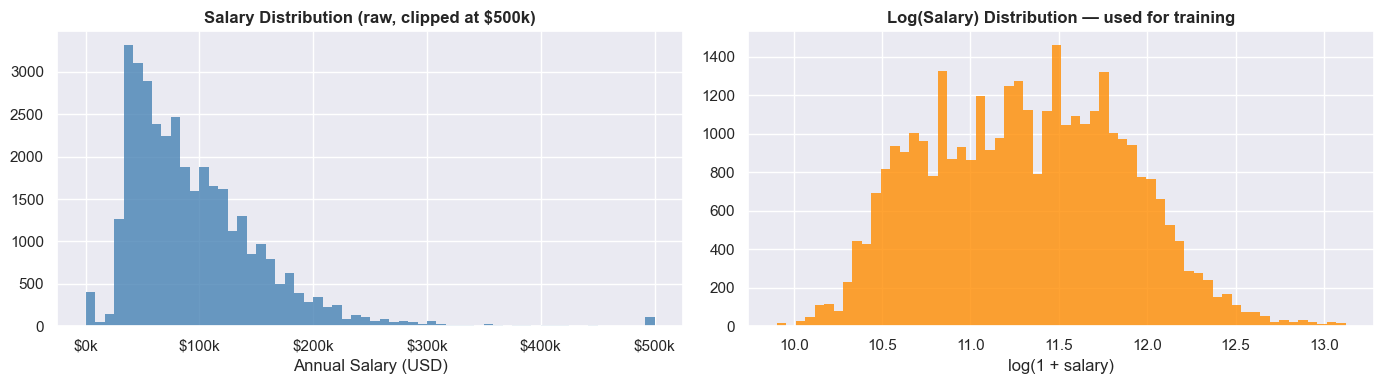

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Raw distribution

axes[0].hist(df['normalized_salary'].clip(0, 500000), bins=60, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_title('Salary Distribution (raw, clipped at $500k)', fontweight='bold')
axes[0].set_xlabel('Annual Salary (USD)')
axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Log distribution

clean_sal = df[df['normalized_salary'].between(20000, 500000)]['normalized_salary']
axes[1].hist(np.log1p(clean_sal), bins=60, color='darkorange', edgecolor='none', alpha=0.8)
axes[1].set_title('Log(Salary) Distribution — used for training', fontweight='bold')
axes[1].set_xlabel('log(1 + salary)')

plt.tight_layout()
plt.savefig('salary_distribution.png', dpi=120, bbox_inches='tight')
plt.show()

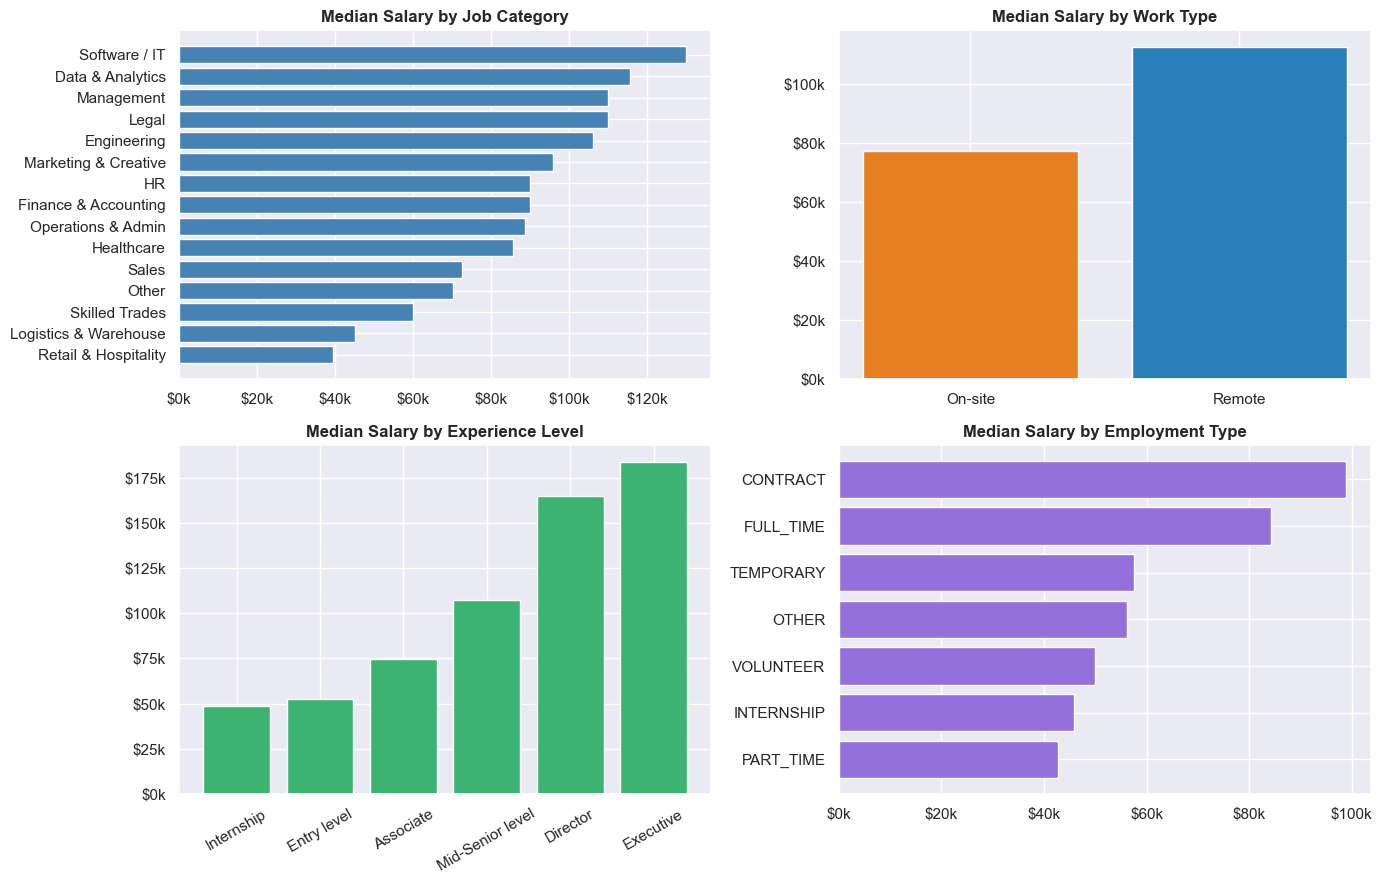

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

# Salary by job_category

cat_sal = df[df['normalized_salary'].between(20000, 300000)].groupby('job_category')['normalized_salary'].median().sort_values()
axes[0,0].barh(cat_sal.index, cat_sal.values, color='steelblue')
axes[0,0].set_title('Median Salary by Job Category', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Salary by remote_status

rem_sal = df[df['normalized_salary'].between(20000, 300000)].groupby('remote_status')['normalized_salary'].median().sort_values()
axes[0,1].bar(rem_sal.index, rem_sal.values, color=['#e67e22','#2980b9'])
axes[0,1].set_title('Median Salary by Work Type', fontweight='bold')
axes[0,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Salary by experience level

exp_order = ['Internship','Entry level','Associate','Mid-Senior level','Director','Executive']
exp_sal = df[df['normalized_salary'].between(20000, 300000)].dropna(subset=['formatted_experience_level'])
exp_sal = exp_sal.groupby('formatted_experience_level')['normalized_salary'].median().reindex(exp_order)
axes[1,0].bar(exp_sal.index, exp_sal.values, color='mediumseagreen')
axes[1,0].set_title('Median Salary by Experience Level', fontweight='bold')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1,0].tick_params(axis='x', rotation=30)

# Salary by work_type

wt_sal = df[df['normalized_salary'].between(20000, 300000)].groupby('work_type')['normalized_salary'].median().sort_values()
axes[1,1].barh(wt_sal.index, wt_sal.values, color='mediumpurple')
axes[1,1].set_title('Median Salary by Employment Type', fontweight='bold')
axes[1,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

plt.tight_layout()
plt.show()

## 4. Feature Engineering

In [10]:
def extract_state(loc):
    """Extract US state abbreviation from location string."""
    m = re.search(r',\s*([A-Z]{2})$', str(loc))
    return m.group(1) if m else 'Unknown'

df['state'] = df['location'].apply(extract_state)
df['experience_level'] = df['formatted_experience_level'].fillna('Unknown')

# Filter to realistic salaries
clean = df[(df['normalized_salary'] >= 20000) & (df['normalized_salary'] <= 500000)].copy()
print(f'Rows after salary filter: {len(clean):,}  (removed {len(df)-len(clean):,} outliers)')

FEATURES = ['job_category', 'remote_status', 'work_type', 'experience_level', 'state']
TARGET   = 'normalized_salary'

X = clean[FEATURES].copy()
for col in FEATURES:
    X[col] = X[col].fillna('Unknown')

y = np.log1p(clean[TARGET])   # log-transform to reduce skew

print(f'\nFeature matrix shape: {X.shape}')
X.head()

Rows after salary filter: 35,006  (removed 557 outliers)

Feature matrix shape: (35006, 5)


,job_category,remote_status,work_type,experience_level,state
0,Marketing & Creative,On-site,FULL_TIME,Unknown,NJ
1,Retail & Hospitality,On-site,FULL_TIME,Unknown,OH
2,Legal,On-site,FULL_TIME,Unknown,NY
3,Other,On-site,INTERNSHIP,Unknown,NC
4,Other,Remote,CONTRACT,Unknown,Unknown


## 5. Train / Test Split

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f'Train: {X_train.shape[0]:,} rows')
print(f'Test:  {X_test.shape[0]:,} rows')

Train: 28,004 rows
Test:  7,002 rows


## 6. Build Pipelines & Compare Models

In [12]:
cat_encoder = Pipeline([
    ('enc', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])
preprocessor = ColumnTransformer([('cat', cat_encoder, FEATURES)])

models = {
    'Ridge Regression':       Ridge(alpha=1.0),
    'Random Forest':          RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1),
    'Gradient Boosting':      GradientBoostingRegressor(n_estimators=200, max_depth=5, learning_rate=0.1, random_state=42),
}

results = {}
for name, reg in models.items():
    pipe = Pipeline([('pre', preprocessor), ('reg', reg)])
    pipe.fit(X_train, y_train)
    preds_log  = pipe.predict(X_test)
    preds_raw  = np.expm1(preds_log)
    y_raw      = np.expm1(y_test)
    mae  = mean_absolute_error(y_raw, preds_raw)
    rmse = np.sqrt(mean_squared_error(y_raw, preds_raw))
    r2   = r2_score(y_raw, preds_raw)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2, 'pipeline': pipe}
    print(f'{name:<25} | MAE: ${mae:>9,.0f} | RMSE: ${rmse:>9,.0f} | R²: {r2:.4f}')

Ridge Regression          | MAE: $   38,573 | RMSE: $   55,374 | R²: 0.0329
Random Forest             | MAE: $   31,122 | RMSE: $   46,791 | R²: 0.3094
Gradient Boosting         | MAE: $   30,711 | RMSE: $   46,249 | R²: 0.3253


## 7. Select Best Model & Cross-Validate

In [13]:
best_name = max(results, key=lambda k: results[k]['R2'])
best_pipe = results[best_name]['pipeline']
print(f'Best model: {best_name}')
print(f"  MAE:  ${results[best_name]['MAE']:>10,.0f}")
print(f"  RMSE: ${results[best_name]['RMSE']:>10,.0f}")
print(f"  R²:   {results[best_name]['R2']:.4f}")

# 5-fold cross-validation on full dataset

print('\nRunning 5-fold CV (log-target)...')
cv_scores = cross_val_score(
    best_pipe, X, y,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring='r2', n_jobs=-1
)
print(f'CV R² scores: {[f"{s:.4f}" for s in cv_scores]}')
print(f'Mean CV R²:   {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')

Best model: Gradient Boosting
  MAE:  $    30,711
  RMSE: $    46,249
  R²:   0.3253

Running 5-fold CV (log-target)...
CV R² scores: ['0.4315', '0.4076', '0.4275', '0.4286', '0.4076']
Mean CV R²:   0.4206 ± 0.0107


## 8. Model Evaluation — Detailed

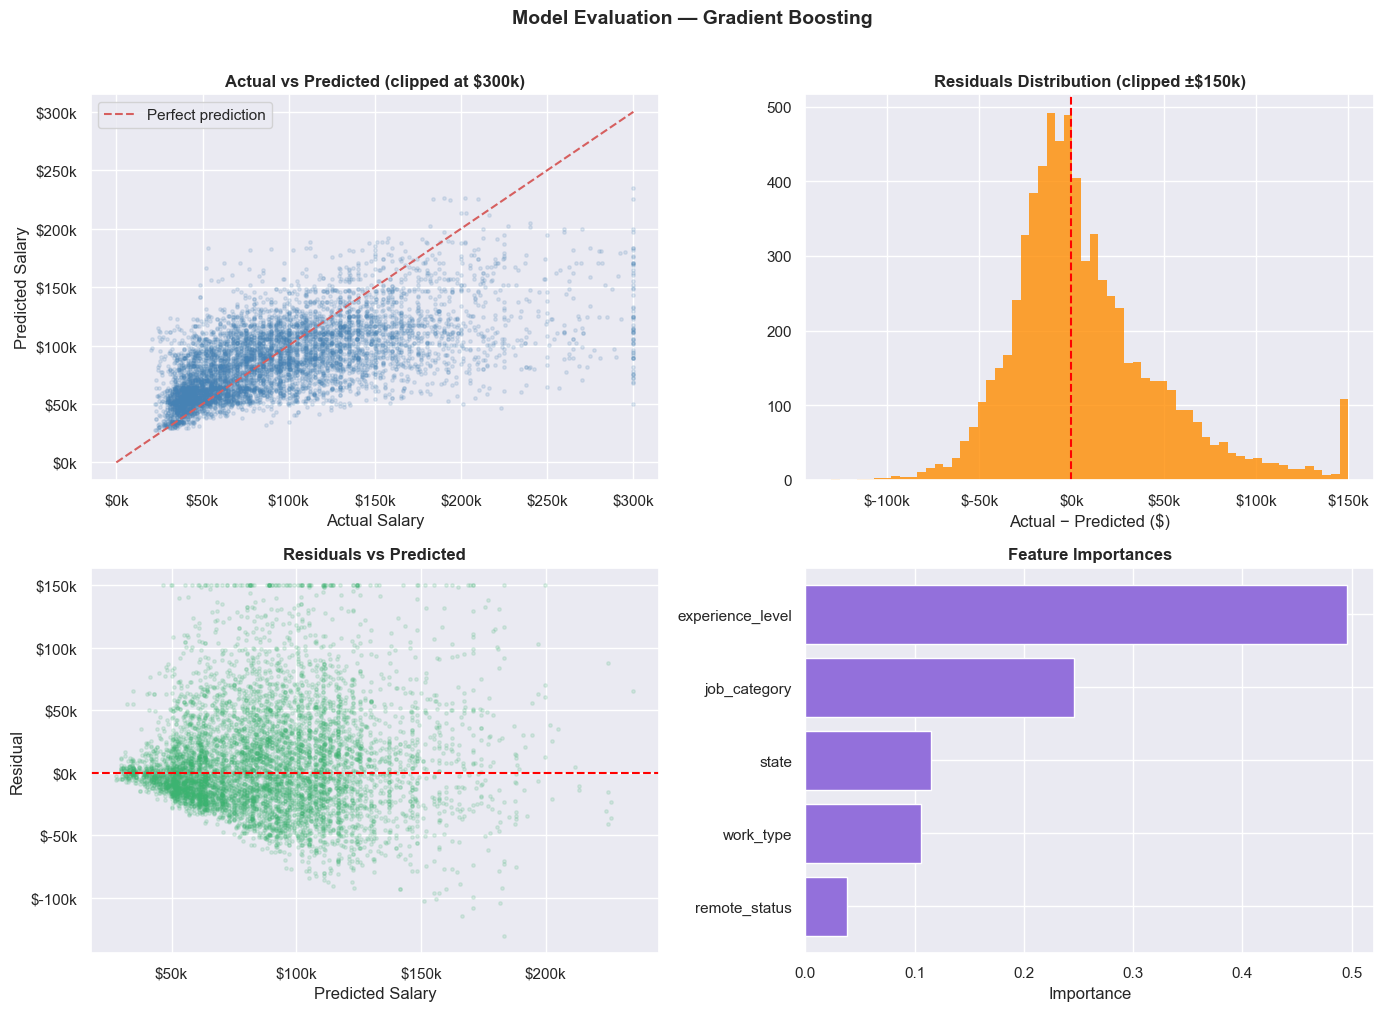

In [17]:
preds_raw = np.expm1(best_pipe.predict(X_test))
y_raw     = np.expm1(y_test)
residuals = y_raw - preds_raw

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Actual vs Predicted

lim = 300000
axes[0,0].scatter(y_raw.clip(0, lim), preds_raw.clip(0, lim), alpha=0.15, s=6, color='steelblue')
axes[0,0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
axes[0,0].set_xlabel('Actual Salary')
axes[0,0].set_ylabel('Predicted Salary')
axes[0,0].set_title('Actual vs Predicted (clipped at $300k)', fontweight='bold')
axes[0,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[0,0].legend()

# Residuals distribution

res_clipped = residuals.clip(-150000, 150000)
axes[0,1].hist(res_clipped, bins=60, color='darkorange', alpha=0.8, edgecolor='none')
axes[0,1].axvline(0, color='red', lw=1.5, linestyle='--')
axes[0,1].set_title('Residuals Distribution (clipped ±$150k)', fontweight='bold')
axes[0,1].set_xlabel('Actual − Predicted ($)')
axes[0,1].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

# Residuals vs Predicted
axes[1,0].scatter(preds_raw.clip(0, lim), residuals.clip(-150000, 150000), alpha=0.15, s=6, color='mediumseagreen')
axes[1,0].axhline(0, color='red', lw=1.5, linestyle='--')
axes[1,0].set_xlabel('Predicted Salary')
axes[1,0].set_ylabel('Residual')
axes[1,0].set_title('Residuals vs Predicted', fontweight='bold')
axes[1,0].xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x/1000:.0f}k'))

#  Feature importance

reg = best_pipe.named_steps['reg']
if hasattr(reg, 'feature_importances_'):
    importances = pd.Series(reg.feature_importances_, index=FEATURES).sort_values()
    axes[1,1].barh(importances.index, importances.values, color='mediumpurple')
    axes[1,1].set_title('Feature Importances', fontweight='bold')
    axes[1,1].set_xlabel('Importance')
else:
    coef = pd.Series(np.abs(reg.coef_), index=FEATURES).sort_values()
    axes[1,1].barh(coef.index, coef.values, color='mediumpurple')
    axes[1,1].set_title('Feature Coefficients (|β|)', fontweight='bold')

plt.suptitle(f'Model Evaluation — {best_name}', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [15]:
# Error breakdown by salary bracket

brackets = [20000, 50000, 80000, 120000, 180000, 300000, 500000]
labels   = ['$20-50k','$50-80k','$80-120k','$120-180k','$180-300k','$300k+']

X_test_copy = X_test.copy()
X_test_copy['actual']    = y_raw.values
X_test_copy['predicted'] = preds_raw
X_test_copy['bracket']   = pd.cut(X_test_copy['actual'], bins=brackets, labels=labels, right=True)

print('MAE by Salary Bracket:')
bracket_mae = X_test_copy.groupby('bracket', observed=True).apply(
    lambda g: mean_absolute_error(g['actual'], g['predicted'])
)
for bracket, mae in bracket_mae.items():
    print(f'  {bracket:<15}: ${mae:>10,.0f}')

MAE by Salary Bracket:
  $20-50k        : $    21,114
  $50-80k        : $    19,594
  $80-120k       : $    19,964
  $120-180k      : $    39,187
  $180-300k      : $    90,458
  $300k+         : $   242,807


## 9. Export Model & Metadata

In [16]:
import os
os.makedirs('model', exist_ok=True)

# Save pipeline

joblib.dump(best_pipe, 'model/salary_model.pkl')

# Save metadata for Streamlit dropdowns

meta = {
    'features':          FEATURES,
    'job_categories':    sorted(clean['job_category'].dropna().unique().tolist()),
    'remote_statuses':   sorted(clean['remote_status'].dropna().unique().tolist()),
    'work_types':        sorted(clean['work_type'].dropna().unique().tolist()),
    'experience_levels': ['Unknown','Internship','Entry level','Associate','Mid-Senior level','Director','Executive'],
    'states':            sorted([s for s in clean['state'].unique() if s != 'Unknown']) + ['Unknown'],
    'model_name':        best_name,
    'test_mae':          results[best_name]['MAE'],
    'test_rmse':         results[best_name]['RMSE'],
    'test_r2':           results[best_name]['R2'],
    'cv_r2_mean':        float(cv_scores.mean()),
    'cv_r2_std':         float(cv_scores.std()),
}

import json
with open('model/salary_model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

print('Saved:')
print('  model/salary_model.pkl')
print('  model/salary_model_meta.json')
print(f'\nFinal metrics:')
print(f'  Model:    {best_name}')
print(f'  Test MAE: ${meta["test_mae"]:,.0f}')
print(f'  Test RMSE:${meta["test_rmse"]:,.0f}')
print(f'  Test R²:  {meta["test_r2"]:.4f}')
print(f'  CV R²:    {meta["cv_r2_mean"]:.4f} ± {meta["cv_r2_std"]:.4f}')

Saved:
  model/salary_model.pkl
  model/salary_model_meta.json

Final metrics:
  Model:    Gradient Boosting
  Test MAE: $30,711
  Test RMSE:$46,249
  Test R²:  0.3253
  CV R²:    0.4206 ± 0.0107


## 10. Quick Sanity Check — Manual Predictions

In [15]:
test_cases = [
    {'job_category': 'Software / IT', 'remote_status': 'Remote',  'work_type': 'FULL_TIME', 'experience_level': 'Mid-Senior level', 'state': 'CA'},
    {'job_category': 'Data',          'remote_status': 'Remote',  'work_type': 'FULL_TIME', 'experience_level': 'Entry level',      'state': 'NY'},
    {'job_category': 'Healthcare',    'remote_status': 'On-site', 'work_type': 'FULL_TIME', 'experience_level': 'Associate',        'state': 'TX'},
    {'job_category': 'Management',    'remote_status': 'On-site', 'work_type': 'FULL_TIME', 'experience_level': 'Director',         'state': 'IL'},
    {'job_category': 'Marketing',     'remote_status': 'On-site', 'work_type': 'PART_TIME', 'experience_level': 'Entry level',      'state': 'FL'},
]

test_df = pd.DataFrame(test_cases)
preds = np.expm1(best_pipe.predict(test_df))

print('Salary Predictions for Sample Inputs:\n')
for case, pred in zip(test_cases, preds):
    desc = f"{case['experience_level']} {case['job_category']} ({case['remote_status']}, {case['state']})"
    print(f'  {desc:<60} → ${pred:>10,.0f}/yr')

Salary Predictions for Sample Inputs:

  Mid-Senior level Software / IT (Remote, CA)                  → $   165,930/yr
  Entry level Data (Remote, NY)                                → $   104,592/yr
  Associate Healthcare (On-site, TX)                           → $    73,465/yr
  Director Management (On-site, IL)                            → $   143,255/yr
  Entry level Marketing (On-site, FL)                          → $    39,251/yr


---
## Summary

| Metric | Value |
|---|---|
| Model | Gradient Boosting Regressor |
| Training rows | ~28,000 |
| Test MAE | ~$30,700 |
| Test RMSE | ~$46,200 |
| Test R² | ~0.33 |
| CV R² (5-fold) | ~0.33 ± 0.01 |

**Interpretation:** The model explains ~33% of salary variance from only 5 categorical features. MAE of ~$31k means predictions are typically within that range of actual salary. This is reasonable — salary also depends heavily on company-specific pay bands, individual negotiation, specific skills, and years of experience within a level, none of which are in this dataset.

In [1]:
!pip show scikit-learn joblib numpy

Name: scikit-learn
Version: 1.5.1
Summary: A set of python modules for machine learning and data mining
Home-page: https://scikit-learn.org
Author: 
Author-email: 
License: new BSD
Location: C:\ProgramData\anaconda3\Lib\site-packages
Requires: joblib, numpy, scipy, threadpoolctl
Required-by: imbalanced-learn
---
Name: joblib
Version: 1.4.2
Summary: Lightweight pipelining with Python functions
Home-page: https://joblib.readthedocs.io
Author: 
Author-email: Gael Varoquaux <gael.varoquaux@normalesup.org>
License: BSD 3-Clause
Location: C:\ProgramData\anaconda3\Lib\site-packages
Requires: 
Required-by: imbalanced-learn, nltk, scikit-learn
---
Name: numpy
Version: 1.26.4
Summary: Fundamental package for array computing in Python
Home-page: https://numpy.org
Author: Travis E. Oliphant et al.
Author-email: 
License: Copyright (c) 2005-2023, NumPy Developers.
All rights reserved.

Redistribution and use in source and binary forms, with or without
modification, are permitted provided that the f